# C9-dimensionality-reduction — Session 1: PCA — Directions That Carry the Variance

*One class session, roughly 80 minutes. Builds on F6-svd-spectral
(`np.linalg.svd`, singular values, the sign pin for eigenvector
comparisons), F5-probability (variance), C1-ml-fundamentals
(unsupervised learning), and F1-scientific-python (broadcasting, seeded
randomness, matplotlib).*

**This session:** what it means for high-dimensional data to be
*secretly low-dimensional*; centering and the mean vector; the sample
variance of the data along a direction; **principal component analysis
(PCA)** by this course's pinned route — **the SVD of the centered data
matrix** — with the component variances $\sigma_i^2/(n-1)$ stated and
verified; the sign-flip ambiguity every eigenvector and singular vector
carries; variance-explained ratios; and a real 2-D projection of a
12-dimensional dataset.

A register note up front: from F6 onward `np.linalg` is a legal tool —
this session leans on `np.linalg.svd` throughout, and each practice
problem states exactly which calls it allows (the exam scopes its bans
per problem the same way).
This unit uses **no sklearn**: it sits outside this unit's prerequisite
chain, so every PCA result here is verified by numerical self-checks
against the SVD route instead of by a library cross-check.

Try every checkpoint by hand first, then verify in code.
Answers are collected at the end of this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Centering: the Mean Vector and $X_c$

**Motivation.**
A dataset of $n$ points in $d$ dimensions is a matrix $X$ of shape
$(n, d)$ — rows are data points, exactly like C8's rows-are-tokens
convention.
Often the $d$ coordinates are not $d$ independent stories: the points
hug a line, a plane, or some other low-dimensional shape, and most
coordinates just re-measure the same underlying variation.
*Dimensionality reduction* is the craft of finding the few directions
that matter.
Every method in this unit starts the same way: move the data's center
of mass to the origin.

**Definition (mean vector, centered matrix).**
The **mean vector** is the average of the rows,
$$\mu = \frac1n \sum_{i} X_i \in \mathbb{R}^d
\qquad\text{(code: } \texttt{X.mean(axis=0)}\text{, shape } (d,)),$$
and the **centered data matrix** is $X_c = X - \mu$, one broadcasted
subtraction.
Centering changes no distances between points and no directions of
variation — it only re-anchors the cloud so that "direction through the
data" and "direction through the origin" mean the same thing.

The demonstration dataset: $200$ points in the plane, built from a
seeded recipe that hides a known direction $(2, 1)/\sqrt5$ under noise
— so we can check every claim against the construction.

In [2]:
SEED = 20260804
rng = np.random.default_rng(SEED)

d_true = np.array([2.0, 1.0]) / np.sqrt(5.0)          # the hidden direction
t = rng.normal(0.0, 3.0, 200)                          # spread along it
noise = rng.normal(0.0, 0.6, (200, 2))                 # isotropic fuzz
X = np.array([5.0, 3.0]) + t[:, None] * d_true + noise

mu = X.mean(axis=0)
Xc = X - mu                                            # (200,2) - (2,) broadcasts
print("X shape:", X.shape)
print("mean vector mu:", np.round(mu, 4))
print("max |column mean of Xc|:", np.max(np.abs(Xc.mean(axis=0))))

X shape: (200, 2)
mean vector mu: [4.4108 2.7544]
max |column mean of Xc|: 2.1094237467877974e-15


The mean vector $(4.4108, 2.7544)$ sits near the construction's
$(5, 3)$ — sampling noise accounts for the gap — and after the
subtraction the column means of $X_c$ are zero to machine precision
($\sim 10^{-15}$).
That is not luck; it is one line of algebra: the mean of
$X_{ij} - \mu_j$ over $i$ is $\mu_j - \mu_j = 0$, column by column.

### Checkpoint 1

1. For $X$ of shape $(n, d)$: what is the shape of `X.mean(axis=0)`,
   and what does `axis=0` average over — rows or columns?
2. Prove in one line that every column of $X_c$ has mean exactly $0$.
3. Predict the printed value of
   `np.round(Xc.mean(axis=0), 12)` before running it.

## 2. Variance Along a Direction

**Motivation.**
"Which direction carries the most variation?" needs a number attached
to each direction before it can have a winner.

**Definition (projection scores, directional variance).**
Fix a **unit** vector $u \in \mathbb{R}^d$.
Each centered point's coordinate along $u$ is its projection score
$z_i = X_{c,i} \cdot u$ — all $n$ of them at once via `z = Xc @ u`,
shape $(n,)$ (F3's matrix–vector action).
Because the columns of $X_c$ have mean $0$, the scores have mean $0$
too, so their **sample variance** is
$$\operatorname{var}(z) \;=\; \frac{1}{n-1} \sum_i z_i^2
\;=\; \frac{\lVert X_c\, u \rVert^2}{n-1}.$$
The $n-1$ is F5 lesson 02 §7½'s sample-variance convention (`ddof=1` in NumPy — a
pitfall in Section 8 shows what forgetting it costs).

In 2-D every direction is $u(\theta) = (\cos\theta, \sin\theta)$, so we
can *sweep* $\theta$ and watch the variance change.

variance along x-axis (0 deg) : 7.9819
variance along y-axis (90 deg): 2.3110
largest variance 9.9651 at theta = 27.0 deg
smallest variance 0.3278 at theta = 117.0 deg


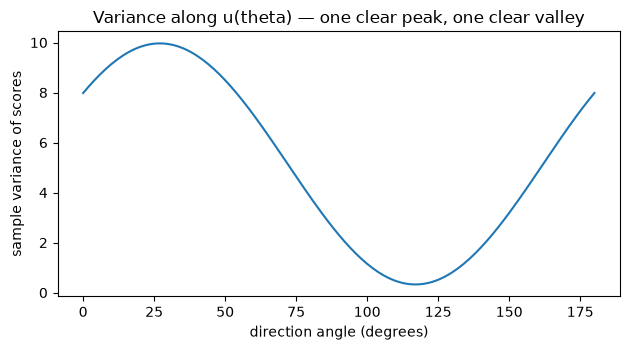

In [3]:
n = X.shape[0]

def var_along(u):
    z = Xc @ u                        # (200,) projection scores
    return (z * z).sum() / (n - 1)    # sample variance (mean is 0)

thetas = np.linspace(0.0, np.pi, 181)          # u and -u tie, so half a turn
sweep = np.array([var_along(np.array([np.cos(th), np.sin(th)])) for th in thetas])

best = int(np.argmax(sweep))
print(f"variance along x-axis (0 deg) : {sweep[0]:.4f}")
print(f"variance along y-axis (90 deg): {sweep[90]:.4f}")
print(f"largest variance {sweep[best]:.4f} at theta = {np.degrees(thetas[best]):.1f} deg")
print(f"smallest variance {sweep.min():.4f} at theta = {np.degrees(thetas[np.argmin(sweep)]):.1f} deg")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(np.degrees(thetas), sweep)
ax.set_xlabel("direction angle (degrees)")
ax.set_ylabel("sample variance of scores")
ax.set_title("Variance along u(theta) — one clear peak, one clear valley")
plt.tight_layout()
plt.show()

The sweep peaks at $27.0^\circ$ with variance $9.9651$ — right on top
of the construction's hidden direction ($\arctan(1/2) = 26.57^\circ$) —
and bottoms out at $117.0^\circ$, exactly $90^\circ$ away, at $0.3278$.
Neither axis direction comes close ($7.98$ and $2.31$): the story of
this dataset runs diagonally, and no single original coordinate tells
it.

A brute-force sweep only works in 2-D — in $d$ dimensions there is no
line of angles to walk.
The next section replaces the sweep with linear algebra.

### Checkpoint 2

1. For unit $u$, what are the shape and the meaning of `Xc @ u`?
2. By hand: $X_c$ has rows $(1, 1)$ and $(-1, -1)$ (so $n = 2$).
   Compute the directional variance along $u = (1, 0)$ and along
   $u = (1, 1)/\sqrt2$.
3. Why does sweeping $\theta$ over $[0, \pi)$ cover every direction —
   what do $u$ and $-u$ share?

## 3. PCA = the SVD of the Centered Data

**The pinned route.**
This course computes PCA one way: **take the SVD of the centered data
matrix**,
$$X_c = U \Sigma V^{\mathsf T},$$
exactly F6's decomposition, applied to $X_c$.
Then — both facts stated here and verified in code:

- the **principal directions** are the rows of $V^{\mathsf T}$
  (equivalently the columns of $V$): $v_1 = $ `Vt[0]` is the direction
  of largest sample variance, $v_2 = $ `Vt[1]` the largest-variance
  direction orthogonal to $v_1$, and so on;
- the **component variances are $\sigma_i^2/(n-1)$**: projecting onto
  $v_i$ gives scores $X_c v_i = \sigma_i u_i$ (F6's
  $W v_i = \sigma_i u_i$ with $W = X_c$), whose squared norm is
  $\sigma_i^2$, so their sample variance is $\sigma_i^2/(n-1)$.

The **scores matrix** collects every point's coordinates in the new
axes: $T = X_c V = U\Sigma$, shape $(n, d)$ — column $i$ of $T$ is the
data seen along $v_i$.
`np.linalg.svd` returns the $\sigma_i$ already sorted descending —
no reordering needed (unlike `eigh`, whose ascending output F6-02
taught you to flip with `[::-1]`).

In [4]:
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
print("thin SVD shapes:", U.shape, s.shape, Vt.shape)
print("singular values:", np.round(s, 4))
assert np.all(np.diff(s) <= 0)                      # descending, as documented

comp_var = s**2 / (n - 1)
print("component variances sigma_i^2/(n-1):", np.round(comp_var, 4))

T = Xc @ Vt.T                                       # scores, = U * s
print("scores route gap:", np.max(np.abs(T - U * s)))

# verify the stated facts against everything we already trust
print("var of PC1 scores (ddof=1):", np.round(np.var(T[:, 0], ddof=1), 4))
print("var of PC2 scores (ddof=1):", np.round(np.var(T[:, 1], ddof=1), 4))
print("sweep's peak variance     :", np.round(sweep[best], 4))
print("PC1 direction Vt[0]:", np.round(Vt[0], 4))
best_u = np.array([np.cos(thetas[best]), np.sin(thetas[best])])
print("|cos(sweep direction, Vt[0])|:", np.abs(best_u @ Vt[0]))

thin SVD shapes: (200, 2) (2,) (2, 2)
singular values: [44.5316  8.0763]
component variances sigma_i^2/(n-1): [9.9651 0.3278]
scores route gap: 6.772360450213455e-15
var of PC1 scores (ddof=1): 9.9651
var of PC2 scores (ddof=1): 0.3278
sweep's peak variance     : 9.9651
PC1 direction Vt[0]: [0.8912 0.4536]
|cos(sweep direction, Vt[0])|: 0.9999999207605765


Every check lands:

- PC1's score variance is $9.9651$ — the sweep's peak to four decimals
  — and PC2's is $0.3278$, the sweep's valley;
- $\sigma = (44.5316,\ 8.0763)$ reproduces both through
  $\sigma_i^2/199$;
- the scores computed as $X_c V$ and as $U\Sigma$ agree to
  $\sim 10^{-15}$;
- `Vt[0]` $= (0.8912, 0.4536)$ points where the sweep pointed
  ($|\cos| \approx 1$ against the $27^\circ$ grid direction — the grid
  is only $1^\circ$ fine, hence the $10^{-8}$ shortfall).

One SVD call replaced the sweep — and, unlike the sweep, it works
unchanged in $d = 100$.
This is the entire computational content of PCA in this course:
**center, `np.linalg.svd`, read off directions and variances.**
No covariance matrix is ever formed — the SVD route goes straight from
data to directions.

### Checkpoint 3

1. Give the thin-SVD shapes of $U$, $\sigma$, $V^{\mathsf T}$ for
   $X_c$ of shape $(200, 2)$.
2. From $\sigma_1 = 44.5316$ and $n = 200$, reproduce PC1's variance
   to four decimals — which formula, and roughly what value?
3. `np.linalg.svd` hands you $\sigma$ descending. Which F6 function
   orders its output the *other* way, and what is the pinned idiom
   that fixes it?

## 4. The Sign-Flip Ambiguity

**The fact (F6-02's pin, reused verbatim).**
If $v$ is a valid principal direction, so is $-v$: both are unit
vectors, both span the same axis, and the variance along them is
identical ($\lVert X_c(-v)\rVert^2 = \lVert X_c v\rVert^2$).
Which of the two your SVD call returns is an implementation accident —
a different NumPy version, or the same data with rows shuffled, can
legitimately flip it.
**Cross-route comparisons of individual vectors therefore either
compare absolute values or sign-fix first: multiply the vector by the
sign of its largest-$|{\cdot}|$ entry, making that entry positive.**

What flips with $v$: the scores column $X_c v$ (negated) and any plot
axis built from it (mirrored).
What does not flip: the variance, the axis itself, and every distance
or shape in a scores plot.

In [5]:
v1 = Vt[0]
print("variance along  v1:", np.round(var_along(v1), 4))
print("variance along -v1:", np.round(var_along(-v1), 4))   # identical

def sign_fix(v):
    return v * np.sign(v[np.argmax(np.abs(v))])   # largest-|entry| made positive

print("sign_fix( v1):", np.round(sign_fix(v1), 4))
print("sign_fix(-v1):", np.round(sign_fix(-v1), 4))          # same vector now

# the safe scalar comparison for two candidate PC1s: |dot| near 1
print("|v1 . (-v1)| =", np.abs(v1 @ -v1))

variance along  v1: 9.9651
variance along -v1: 9.9651
sign_fix( v1): [0.8912 0.4536]
sign_fix(-v1): [0.8912 0.4536]
|v1 . (-v1)| = 1.0


Both flips of $v_1$ report variance $9.9651$, and `sign_fix` maps both
to the same representative $(0.8912, 0.4536)$.
When a practice problem pins a principal direction as an anchor, it
pins the **sign-fixed** form — your job is to apply `sign_fix` before
comparing, or to compare $|v \cdot v_{\text{anchor}}|$ to $1$.

### Checkpoint 4

1. Replacing $v_1$ by $-v_1$: what happens to the scores column, to
   its variance, and to a scatter plot of the scores?
2. Apply the sign-fix to $v = (-0.3, 0.5, -0.8)$.
3. A teammate's PC1 is `w`. Write one expression using `np.abs` that
   returns (approximately) `1.0` exactly when `w` and your `v1` span
   the same axis.

## 5. Variance-Explained Ratios

**Definition.**
Component $i$'s **variance-explained ratio** is its share of the total:
$$\mathrm{evr}_i
\;=\; \frac{\sigma_i^2/(n-1)}{\sum_j \sigma_j^2/(n-1)}
\;=\; \frac{\sigma_i^2}{\sum_j \sigma_j^2}
— the $n-1$ cancels.$$
Three facts make this number trustworthy (practice p11 turns them into
a graded proof):

- the **total** sample variance of the data — the sum of the $d$
  per-column `ddof=1` variances — equals
  $\lVert X_c \rVert_F^2/(n-1)$, which by F6-04's identity
  $\lVert X_c \rVert_F^2 = \sum_i \sigma_i^2$ is exactly
  $\sum_i \sigma_i^2/(n-1)$;
- so the component variances **partition the total**: variance is
  neither created nor lost by rotating to the principal axes;
- and the ratios **sum to exactly $1$**.

In [6]:
evr = s**2 / (s**2).sum()
print("variance-explained ratios:", np.round(evr, 4))
print("cumulative:", np.round(np.cumsum(evr), 4))
assert np.isclose(evr.sum(), 1.0, atol=1e-12, rtol=0)

total_by_columns = X.var(axis=0, ddof=1).sum()      # route 1: per-feature
total_by_sigma = comp_var.sum()                     # route 2: through the SVD
print("total variance, column route:", np.round(total_by_columns, 4))
print("total variance, sigma route :", np.round(total_by_sigma, 4))
print("gap:", np.abs(total_by_columns - total_by_sigma))

variance-explained ratios: [0.9682 0.0318]
cumulative: [0.9682 1.    ]
total variance, column route: 10.2929
total variance, sigma route : 10.2929
gap: 1.7763568394002505e-15


PC1 explains $96.82\%$ of this dataset's variance; PC2 mops up the
remaining $3.18\%$.
The two total-variance routes — never touching the SVD vs entirely
through it — agree at $10.2929$ with a gap at machine scale.
That agreement is this unit's substitute for a library cross-check:
two independent computations, one number.

Reading the ratios is a judgment call the exam likes to probe: an
`evr` of $(0.9682, 0.0318)$ says a 1-D summary of this 2-D dataset
loses only $3\%$ of the variance — this data is *secretly
one-dimensional*, which is exactly how it was built.

### Checkpoint 5

1. Why does $\mathrm{evr}_i$ not depend on whether variances use $n$
   or $n-1$?
2. By hand: $\sigma = (4, 3)$. Compute both ratios.
3. For our toy data, what does the cumulative list $(0.9682, 1.0)$
   say about compressing it to one dimension?


### Bias-variance callback: EVR, capacity, and the train-test gap

C1 placed models on a rigid-to-flexible spectrum; F5 now lets us make
the word **variance** precise.  In the bias-variance tradeoff, variance
means how much the fitted rule would change across different training
samples from the same population.  That is distinct from PCA's
variance-explained ratio: `evr` measures spread of the **feature data**
along a direction inside this one dataset.

Retaining a larger rank $r$ raises representational **capacity**: the
downstream rule receives more coordinates and can respond to finer
sample-specific directions.  At very small $r$, discarded real signal can
produce underfitting — training and test scores are both poor and close.
At very large $r$, training score can keep improving while test score
falls, producing the large train-test gap that marks overfitting and
high sample-to-sample variance.  High cumulative EVR is therefore not a
deployment certificate: choose $r$ on held-out training data, and reserve
the test set for the final estimate.


## 6. A Real Projection: 12 Dimensions onto 2

**The payoff.**
Twelve-dimensional data cannot be scattered on a screen; its top-2
principal components can.
The **2-D PCA projection** keeps the first two scores columns
$T_{:,0}, T_{:,1}$ — each point's coordinates along $v_1, v_2$ — and
drops the other ten.
The recipe is the same three lines, at any $d$.

The dataset: three seeded clusters in $\mathbb{R}^{12}$, built with
known labels so we can judge what the projection preserves.
(PCA never sees the labels — it is unsupervised, C1's sense; the colors
below are our after-the-fact audit.)

evr, first four: [0.5259 0.3755 0.0142 0.0126]
top-2 cumulative: 0.9014


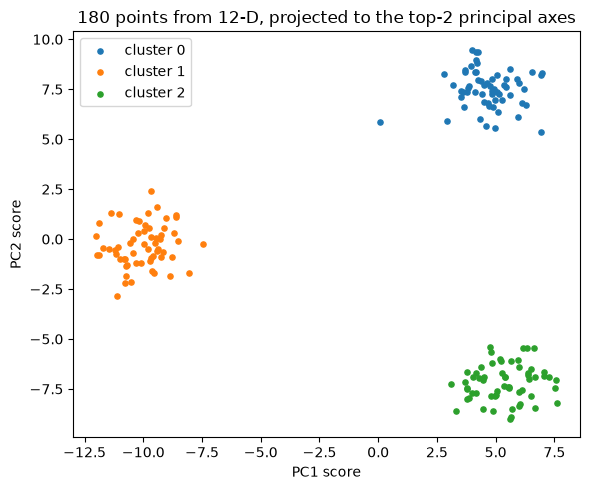

In [7]:
rng = np.random.default_rng(SEED)
centers = rng.normal(0.0, 3.0, (3, 12))
labels = np.repeat(np.arange(3), 60)                  # 60 points per cluster
X12 = centers[labels] + rng.normal(0.0, 1.0, (180, 12))

mu12 = X12.mean(axis=0)
Xc12 = X12 - mu12
U12, s12, Vt12 = np.linalg.svd(Xc12, full_matrices=False)
T12 = Xc12 @ Vt12.T
evr12 = s12**2 / (s12**2).sum()
print("evr, first four:", np.round(evr12[:4], 4))
print("top-2 cumulative:", np.round(evr12[:2].sum(), 4))

fig, ax = plt.subplots(figsize=(6.0, 5.0))
for g, color in zip(range(3), ["tab:blue", "tab:orange", "tab:green"]):
    pts = T12[labels == g]
    ax.scatter(pts[:, 0], pts[:, 1], s=14, color=color, label=f"cluster {g}")
ax.set_xlabel("PC1 score")
ax.set_ylabel("PC2 score")
ax.set_title("180 points from 12-D, projected to the top-2 principal axes")
ax.legend()
plt.tight_layout()
plt.show()

Three clean islands.
The top two components carry $90.14\%$ of the variance
($52.59\% + 37.55\%$, with every remaining component under $1.5\%$) —
the between-cluster separation *is* this dataset's variance, so the
top-2 plane runs through the cluster centers almost exactly.
The audit below makes that quantitative: distances between cluster
means barely shrink under the projection.

In [8]:
for a, b in [(0, 1), (0, 2), (1, 2)]:
    full = X12[labels == a].mean(axis=0) - X12[labels == b].mean(axis=0)
    d_full = np.sqrt((full * full).sum())
    proj = T12[labels == a, :2].mean(axis=0) - T12[labels == b, :2].mean(axis=0)
    d_proj = np.sqrt((proj * proj).sum())
    print(f"clusters {a}-{b}: distance {d_full:7.3f} in 12-D, {d_proj:7.3f} in the 2-D projection")

clusters 0-1: distance  16.678 in 12-D,  16.678 in the 2-D projection
clusters 0-2: distance  14.712 in 12-D,  14.711 in the 2-D projection
clusters 1-2: distance  16.883 in 12-D,  16.883 in the 2-D projection


All three separations survive essentially unchanged — at three
decimals the only visible change is $14.712 \to 14.711$.
A warning for Session 3, stated now: this near-perfect preservation is
a property of *this* dataset — cluster blobs whose separation happens
to be the dominant variance — **not** of PCA in general.
Session 3 builds a dataset where the top-2 PCA plane keeps $90\%$ of
the variance and still scrambles the local structure.

### Checkpoint 6

1. What is the shape of `T12[:, :2]`, and what does row $i$ of it
   contain?
2. Top-2 cumulative evr is $0.9014$. What fraction of the total
   variance did the scatter plot throw away?
3. Distances between cluster means shrank, if only barely. Could a
   PCA projection ever make a distance *larger*? Why not?

## 7. Worked Exam-Style Example: Numeric Normal-Form MC

PCA arithmetic small enough for a pencil, in the exam's normal-form
device.
Worked in full.

---

**Problem.**
Four data points in $\mathbb{R}^2$:
$$(5, 3),\quad (1, -1),\quad (4, 0),\quad (2, 2).$$
Center the data, and let $\sigma_1 \ge \sigma_2$ be the singular values
of the centered matrix $X_c$.
The variance-explained ratio of the first principal component is a
rational number, in lowest terms $p/q$ with $\gcd(p, q) = 1$, $q > 0$.
What is $p + q$?

A. $5$  B. $6$  C. $9$  D. $17$  E. $36$

*Reasoning is not required (but we reason anyway).*

---

**Step 1 — center.**
$\mu = \left(\tfrac{5+1+4+2}{4}, \tfrac{3-1+0+2}{4}\right) = (3, 1)$,
so the centered rows are
$$(2, 2),\quad (-2, -2),\quad (1, -1),\quad (-1, 1).$$

**Step 2 — singular values by F6's hand route.**
F6-03's bridge, applied to $X_c^{\mathsf T}$ (whose SVD swaps the roles
of $U$ and $V$): the nonzero eigenvalues of the $2 \times 2$ Gram
matrix $X_c^{\mathsf T} X_c$ are the $\sigma_i^2$.
Its entries are sums over the four rows:
$$X_c^{\mathsf T} X_c =
\begin{pmatrix} 4+4+1+1 & 4+4-1-1 \\ 4+4-1-1 & 4+4+1+1 \end{pmatrix}
= \begin{pmatrix} 10 & 6 \\ 6 & 10 \end{pmatrix}.$$
F6-01's $2\times2$ eigenvalue condition: $(10-\lambda)^2 - 36 = 0$, so
$10 - \lambda = \pm 6$ and $\lambda = 16, 4$.
Hence $\sigma_1^2 = 16$, $\sigma_2^2 = 4$ (i.e. $\sigma = 4, 2$).

**Step 3 — the ratio, in normal form.**
$$\mathrm{evr}_1 = \frac{\sigma_1^2}{\sigma_1^2 + \sigma_2^2}
= \frac{16}{20} = \frac{4}{5}
\qquad (\gcd(4,5) = 1,\ q = 5 > 0).$$

**Step 4 — decode.**
$p + q = 4 + 5 = 9$ — answer **C**.
The traps are manufactured from real mistakes: A is forgetting to
square ($\sigma_1/(\sigma_1{+}\sigma_2) = 4/6 = 2/3 \to 5$); B is
reporting PC2's ratio ($1/5 \to 6$); D squares only the numerator
($16/(16+2) = 8/9 \to 17$); E decodes the unreduced $16/20 \to 36$.
Note what the ratio never needed: the $n-1$. It cancels — but the
*component variances themselves* are $16/3$ and $4/3$, and a problem
asking for those would need the division.

In [9]:
Xw = np.array([[5.0, 3.0], [1.0, -1.0], [4.0, 0.0], [2.0, 2.0]])
Xwc = Xw - Xw.mean(axis=0)
_, sw, Vtw = np.linalg.svd(Xwc, full_matrices=False)
print("sigma:", np.round(sw, 6))
print("component variances:", np.round(sw**2 / 3, 6))
print("evr:", sw**2 / (sw**2).sum(), "-> 4/5 -> p + q = 9 -> answer C")

sigma: [4. 2.]
component variances: [5.333333 1.333333]
evr: [0.8 0.2] -> 4/5 -> p + q = 9 -> answer C


### Checkpoint 7

1. Rework the example with raw points
   $(4, 4), (-2, -2), (2, 0), (0, 2)$: center, get $\sigma$ through
   the Gram route, and decode $p + q$ for PC1's ratio.
2. Why is it *guaranteed* that all the variance-explained ratios of
   any dataset sum to exactly $1$? (One sentence; p11 grades the full
   argument.)

## 8. Common Pitfalls

**Pitfall 1 — skipping the centering (quiet).**
The SVD of *uncentered* data answers a different question: its first
direction chases the mean, not the variance.
The demo shifts our centered cloud to sit at $(12, -9)$ and takes the
SVD without re-centering.

In [10]:
Xs = Xc + np.array([12.0, -9.0])          # same shape of cloud, off-origin
_, s_shift, Vt_shift = np.linalg.svd(Xs, full_matrices=False)
v1_shift = Vt_shift[0]
print("uncentered sigma:", np.round(s_shift, 3), " (centered was:", np.round(s, 3), ")")
print("uncentered v1:", np.round(v1_shift, 4))
print("|cos(v1_shift, mean direction)|:", np.round(np.abs(v1_shift @ np.array([0.8, -0.6])), 4))
print("|cos(v1_shift, true PC1)|      :", np.round(np.abs(v1_shift @ Vt[0]), 4))

uncentered sigma: [213.192  39.967]  (centered was: [44.532  8.076] )
uncentered v1: [-0.8103  0.5861]
|cos(v1_shift, mean direction)|: 0.9999
|cos(v1_shift, true PC1)|      : 0.4562


The uncentered "PC1" aligns with the mean direction $(0.8, -0.6)$ at
$|\cos| = 0.9999$ and with the true principal direction at only
$0.4562$; its leading singular value balloons to $213$ because it now
measures distance-from-origin, not spread.
Nothing raised — the classic quiet bug.
The habit that catches it: **assert the column means of what you feed
`svd` are (numerically) zero.**

**Pitfall 2 — `np.var`'s default `ddof=0` (quiet).**
NumPy divides by $n$ unless told otherwise; the course convention (and
F5's estimator) divides by $n-1$.

In [11]:
z0 = T[:, 0]
print("np.var(z0)        :", np.round(np.var(z0), 4))          # divides by n
print("np.var(z0, ddof=1):", np.round(np.var(z0, ddof=1), 4))  # divides by n-1
print("sigma^2/(n-1)     :", np.round(s[0]**2 / (n - 1), 4))

np.var(z0)        : 9.9153
np.var(z0, ddof=1): 9.9651
sigma^2/(n-1)     : 9.9651


$9.9153$ vs $9.9651$ — a half-percent error at $n = 200$, silently, in
every variance you report.
Any anchor check at `atol=1e-4` fails loudly on the mismatch; that is
what anchors are for.

**Pitfall 3 — comparing directions without the sign pin (quiet, then
loud at the worst time).**
`assert np.allclose(my_v1, anchor_v1)` works on your machine, then
fails in the graded rerun because the SVD legitimately flipped the
sign.
Section 4's rule: sign-fix both, or compare $|v \cdot w|$.

**Pitfall 4 — indexing $V^{\mathsf T}$ as if it were $V$ (quiet in
2-D, loud only sometimes).**
Directions are **rows** of `Vt`.
`Vt[:, 0]` grabs a *column* — which in 2-D is still some unit vector,
so nothing raises; it is simply not a principal direction.

In [12]:
print("variance along Vt[0]   (a row)  :", np.round(var_along(Vt[0]), 4))
print("variance along Vt[:, 0] (a column):", np.round(var_along(Vt[:, 0]), 4))

variance along Vt[0]   (a row)  : 9.9651
variance along Vt[:, 0] (a column): 3.6647


$9.9651$ vs $3.6647$: the column is a blend of the two principal
directions, and its variance is a meaningless in-between number.
In higher dimensions the same slip sometimes crashes on shapes and
sometimes doesn't — never rely on the crash.

### Checkpoint 8

1. Classify pitfalls 1, 2, and 4 as *loud* or *quiet*, and give the
   one-line self-check that catches pitfall 1.
2. A teammate reports PC1 variance $9.9153$ on the toy dataset.
   Which pitfall, and how do you know at a glance?
3. Write the assert that pins `comp_var[0]` to the anchor $9.9651$ at
   `atol=1e-4` under this course's isclose contract.

## Checkpoint Answers

<details><summary><b>Checkpoint 1</b></summary>

1. Shape $(d,)$; `axis=0` averages over the rows (down each column),
   one mean per feature.
2. Column $j$ of $X_c$ has mean
   $\frac1n\sum_i (X_{ij} - \mu_j) = \mu_j - \mu_j = 0$.
3. `[0. 0.]` — the exact zeros survive rounding to 12 places because
   the residual is $\sim 10^{-15}$.

</details>

<details><summary><b>Checkpoint 2</b></summary>

1. Shape $(n,)$: entry $i$ is $X_{c,i} \cdot u$, point $i$'s
   coordinate along the axis $u$.
2. Along $(1, 0)$: scores $(1, -1)$, variance
   $\frac{1^2 + (-1)^2}{2-1} = 2$.
   Along $(1,1)/\sqrt2$: scores $(\sqrt2, -\sqrt2)$, variance
   $\frac{2 + 2}{1} = 4$.
3. $u$ and $-u$ give the same variance (the scores only change sign),
   so directions $\pi$ apart are duplicates — half a turn covers all.

</details>

<details><summary><b>Checkpoint 3</b></summary>

1. $U$: $(200, 2)$, $\sigma$: $(2,)$, $V^{\mathsf T}$: $(2, 2)$.
2. $\sigma_1^2/(n-1) = 44.5316^2 / 199 \approx 9.9651$.
3. `np.linalg.eigh` returns eigenvalues *ascending*; the pinned idiom
   is `vals[::-1]` with the matching `vecs[:, ::-1]`.

</details>

<details><summary><b>Checkpoint 4</b></summary>

1. The scores column negates; the variance is unchanged; the scatter
   mirrors across the other axis — same shapes, same distances.
2. Largest $|{\cdot}|$ entry is $-0.8$, whose sign is $-1$:
   the fix returns $(0.3, -0.5, 0.8)$.
3. `np.abs(w @ v1)` — approximately $1.0$ exactly when they span the
   same axis (any residual is numerical noise).

</details>

<details><summary><b>Checkpoint 5</b></summary>

1. Both numerator and denominator carry the same $1/(n-1)$ (or $1/n$)
   factor, which cancels in the ratio.
2. $\mathrm{evr} = (16/25, 9/25) = (0.64, 0.36)$.
3. Keeping only PC1 preserves $96.82\%$ of the variance — a 1-D
   version of this dataset is nearly lossless.

</details>

<details><summary><b>Checkpoint 6</b></summary>

1. $(180, 2)$; row $i$ holds point $i$'s coordinates along $v_1$ and
   $v_2$.
2. $1 - 0.9014 = 0.0986$, just under $10\%$.
3. No. The projection keeps two coordinates of each difference vector
   in the rotated (orthonormal) axes and drops the rest, so squared
   distances can only lose terms: $d_{\text{proj}} \le d_{\text{full}}$
   always.

</details>

<details><summary><b>Checkpoint 7</b></summary>

1. $\mu = (1, 1)$; centered rows $(3,3), (-3,-3), (1,-1), (-1,1)$;
   Gram $\begin{pmatrix} 20 & 16 \\ 16 & 20 \end{pmatrix}$;
   $(20-\lambda)^2 = 256 \Rightarrow \lambda = 36, 4$, so
   $\sigma = (6, 2)$; $\mathrm{evr}_1 = 36/40 = 9/10$;
   $p + q = 19$.
2. Because the component variances sum to the total variance (the
   $\sigma_i^2$ partition $\lVert X_c\rVert_F^2$), dividing by that
   total makes the shares sum to $1$.

</details>

<details><summary><b>Checkpoint 8</b></summary>

1. All three are quiet (pitfall 4 is loud only in some shapes — never
   rely on it). For pitfall 1:
   `assert np.max(np.abs(Xc.mean(axis=0))) < 1e-10`.
2. Pitfall 2: $9.9153$ is exactly the `ddof=0` value — the ratio
   $9.9153/9.9651 = 199/200$ is the giveaway.
3. `assert np.isclose(comp_var[0], 9.9651, atol=1e-4, rtol=0)`.

</details>